# Radio Occultation Validation: PlanetiQ

This notebook repeats the [COSMIC-2 radio occultation validation](ValidateROCOSMIC2.ipynb) for receivers in polar orbits: [PlanetiQ](https://www.planetiq.com/)'s GNOMES-4 and GNOMES-5 satellites, receiving GPS, GLONASS, and Galileo signals on the same day, 14 May 2026. COSMIC-2's 24 deg orbit inclination confines its tangent points to roughly ±45 deg latitude; the GNOMES satellites fly sun-synchronous orbits (97.5 and 97.7 deg inclination, about 570 km altitude) and sample every latitude, including the polar regions. As in the COSMIC-2 notebook, TAT-C models each occultation with the straight line between receiver and transmitter (refraction is not modeled) and reports the line's tangent point, its point of minimum WGS 84 geodetic altitude.

`collect_ro_observations` is run end to end with published orbits for the day, and its predictions are compared with every GPS, GLONASS, and Galileo occultation PlanetiQ recorded, separately for each constellation:

1. **Orbits.** How closely do published orbits reproduce the recorded satellite positions?
2. **Predicted and observed occultations.** Does TAT-C predict the occultations that were observed, and how many more?
3. **Detection.** Which predicted occultations were actually recorded, and why not the others?
4. **Timing and location.** How accurate are the time and position TAT-C reports for each matched occultation?

## Reference Data

GNSS RO data from several missions and processing centers are available in the [AWS Registry of Open Data](https://registry.opendata.aws/gnss-ro-opendata/) (no account required), with a metadata database that the [`awsgnssroutils`](https://pypi.org/project/awsgnssroutils/) package can query (`pip install awsgnssroutils netCDF4`). This notebook uses UCAR's PlanetiQ processing for 14 May 2026, the same day as the COSMIC-2 validation. The database lists every occultation recorded that day, with its receiver, transmitter, and rising or setting flag, and each occultation's **calibratedPhase** (Level 1A) file records the receiver and transmitter positions in Earth-centered, Earth-fixed coordinates, sampled at 100 Hz (transmitter positions at the time of signal transmission).

Of the 5,425 PlanetiQ occultations that day, 1,332 from GPS, 1,031 from GLONASS, and 1,325 from Galileo have a retrieval (that is, passed UCAR's processing); PlanetiQ also tracks BeiDou, which is not included here. A seeded random sample of 200 from each constellation is used to identify the satellites and check their orbits (Test 1) and to check TAT-C's timing and location against the recorded positions (Test 4); their Level 1A files (about 1.4 GB) are downloaded once to a local `data/ro` directory (shared with the COSMIC-2 notebook).

In [1]:
import os

import numpy as np
from awsgnssroutils.database import RODatabaseClient

CONSTELLATIONS = {"G": "GPS", "R": "GLONASS", "E": "Galileo"}

DATA_DIR = os.path.join("data", "ro")
rodb = RODatabaseClient(metadata_root=os.path.join(DATA_DIR, "metadata"), version="v1.1")
occultations = rodb.query(
    missions="planetiq", datetimerange=("2026-05-14", "2026-05-14T23:59:59"), silent=True
)
# seeded random sample of 200 occultations with a retrieval from each constellation
sample = occultations[0:0]
sample._data = []
for k, code in enumerate(CONSTELLATIONS):
    pool = occultations.filter(
        GNSSconstellations=code,
        availablefiletypes=["ucar_calibratedPhase", "ucar_refractivityRetrieval"],
    )
    rng = np.random.default_rng(20260514 + k)
    sample._data += [pool._data[i] for i in sorted(rng.choice(pool.size, 200, replace=False))]
    print(f"{CONSTELLATIONS[code]}: {pool.size} occultations with a retrieval, 200 sampled")
sample.size = len(sample._data)
# flat layout keeps local paths short (Windows limits paths to 260 characters)
sample.download("ucar_calibratedPhase", data_root=DATA_DIR, keep_aws_structure=False, silent=True)
print(f"{occultations.size} PlanetiQ occultations on 14 May 2026, {sample.size} sampled")

GPS: 1332 occultations with a retrieval, 200 sampled
GLONASS: 1031 occultations with a retrieval, 200 sampled
Galileo: 1325 occultations with a retrieval, 200 sampled
5425 PlanetiQ occultations on 14 May 2026, 600 sampled


## Test 1: Orbits

`collect_ro_observations` needs orbits for the day: two-line element sets (TLEs) for the GPS, GLONASS, and Galileo satellites, shared with the COSMIC-2 notebook as `gps_2026-05-14.3le`, `glonass_2026-05-14.3le`, and `galileo_2026-05-14.3le` (see that notebook for their queries), and for the GNOMES satellites, included with this notebook as `planetiq_2026-05-14.3le`. The GNOMES element sets were obtained from [Space-Track](https://www.space-track.org) (free account required) with the `gp_history` query

```
https://www.space-track.org/basicspacedata/query/class/gp_history/NORAD_CAT_ID/46266,52158,58462,60574/EPOCH/2026-05-13--2026-05-16/orderby/NORAD_CAT_ID%20asc,EPOCH%20asc/format/3le
```

which includes GNOMES-1 and GNOMES-3 as additional candidates for the identification below.

Transmitters are identified in RO data by their PRN code (or GLONASS slot number), which TLEs do not carry, and individual element sets can be poor (for example, around a maneuver). Each receiver and transmitter is therefore matched to the satellite whose element sets best reproduce the positions recorded in the sampled Level 1A files (at the start, middle, and end of each occultation), with the satellites of all three constellations as candidates. Every element set of the matched satellite is then checked against those positions, and any set more than 20 km away is excluded; a transmitter whose element sets all fail this check is left out. The identification, like the other time-consuming steps below, runs in parallel worker processes (with `joblib`).

In [2]:
import collections
from datetime import datetime, timedelta, timezone

import netCDF4 as nc
import pandas as pd
from joblib import Parallel, delayed

from tatc.constants import timescale
from tatc.schemas import GeneralPerturbationsOrbit, Satellite

DAY0 = datetime(2026, 5, 14, tzinfo=timezone.utc)
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
GPS_UTC_OFFSET = 18  # s, GPS time minus UTC in 2026
MAX_ERROR = 20  # km, largest acceptable position error of an element set
N_JOBS = min(16, os.cpu_count())  # parallel worker processes

# element sets per NORAD catalog number, keyed by epoch (later duplicates win)
tle_lines = [
    line.rstrip()
    for path in ["gps_2026-05-14.3le", "glonass_2026-05-14.3le", "galileo_2026-05-14.3le", "planetiq_2026-05-14.3le"]
    for line in open(path)
    if line.strip()
]
element_sets, names = collections.defaultdict(dict), {}
for i in range(0, len(tle_lines), 3):
    line1, line2 = tle_lines[i + 1], tle_lines[i + 2]
    names[line1[2:7]] = tle_lines[i][2:].strip()
    element_sets[line1[2:7]][float(line1[18:32])] = [line1, line2]


def to_orbit(sets):
    return GeneralPerturbationsOrbit.from_tle(sum((sets[e] for e in sorted(sets)), []))


def identify(positions, element_sets, max_error):
    """Matches recorded Earth-fixed positions [(datetime, m)] to the satellite whose element sets
    reproduce them best, keeping that satellite's element sets within max_error (km) of all of them.
    Returns the NORAD catalog number, kept element sets, their position errors (km), the next-best
    satellite's median error (km), and the number of excluded element sets."""
    import numpy as np
    from skyfield.framelib import itrs

    from tatc.constants import timescale
    from tatc.schemas import GeneralPerturbationsOrbit

    ts = timescale.from_datetimes([t for t, _ in positions])
    rotation = itrs.rotation_at(ts)
    recorded_m = np.array([p for _, p in positions]).T

    def errors(sets):
        orbit = GeneralPerturbationsOrbit.from_tle(sum((sets[e] for e in sorted(sets)), []))
        p = np.einsum("ij...,j...->i...", rotation, np.array(orbit.get_orbit_track_at_time(ts).position.m))
        return np.linalg.norm(p - recorded_m, axis=0) / 1e3

    best = {norad: min(np.median(errors({e: s})) for e, s in sets.items()) for norad, sets in element_sets.items()}
    norad = min(best, key=best.get)
    kept = {e: s for e, s in element_sets[norad].items() if errors({e: s}).max() <= max_error}
    return norad, kept, errors(kept) if kept else None, sorted(best.values())[1], len(element_sets[norad]) - len(kept)


# recorded positions of each receiver and transmitter
recorded = collections.defaultdict(list)
for record in sample._data:
    l1 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_calibratedPhase"])))
    l1.set_auto_mask(False)
    for k in [0, l1["time"].size // 2, l1["time"].size - 1]:
        t = GPS_EPOCH + timedelta(seconds=float(l1["startTime"][...]) - GPS_UTC_OFFSET + float(l1["time"][k]))
        recorded[record["transmitter"]].append((t, l1["positionGNSS"][k].astype(float)))
        recorded[record["receiver"]].append((t, l1["positionLEO"][k].astype(float)))


keys = sorted(recorded)
results = Parallel(n_jobs=N_JOBS)(delayed(identify)(recorded[key], element_sets, MAX_ERROR) for key in keys)
rows, satellites = [], {}
for key, (norad, kept, errors, next_best, excluded) in zip(keys, results):
    row = {"key": key, "NORAD": norad, "name": names[norad], "element sets": len(kept), "excluded sets": excluded}
    if kept:  # identified: at least one element set reproduces the recorded positions
        satellites[key] = Satellite(name=key, orbit=to_orbit(kept))
        row.update({"median error (km)": np.median(errors), "max error (km)": errors.max()})
    row["next-best satellite (km)"] = next_best
    rows.append(row)
orbit_check = pd.DataFrame(rows).set_index("key")
orbit_check["group"] = [CONSTELLATIONS.get(k[0], "receivers") for k in keys]
receivers = [satellites[k] for k in sorted(satellites) if k.startswith("planetiq")]
transmitters = [satellites[k] for k in sorted(satellites) if k[0] in CONSTELLATIONS]
unidentified = sorted(k for k in recorded if k not in satellites)
print(f"{len(receivers)} receivers and {len(transmitters)} transmitters identified; unidentified: {unidentified or 'none'}")
display(orbit_check[orbit_check["excluded sets"] > 0].round(2))  # element sets excluded as poor
orbit_check.groupby("group", sort=False).agg(
    **{
        "satellites": ("NORAD", "size"),
        "median error (km)": ("median error (km)", "median"),
        "max error (km)": ("max error (km)", "max"),
        "excluded sets": ("excluded sets", "sum"),
        "closest next-best satellite (km)": ("next-best satellite (km)", "min"),
    }
).round(2)

2 receivers and 71 transmitters identified; unidentified: none


,NORAD,name,element sets,excluded sets,median error (km),max error (km),next-best satellite (km),group
key,,,,,,,,


,satellites,median error (km),max error (km),excluded sets,closest next-best satellite (km)
group,,,,,
Galileo,26,1.57,15.55,0,5397.55
GPS,26,1.29,4.68,0,1829.72
GLONASS,19,1.50,6.83,0,3838.58
receivers,2,0.62,1.39,0,2330.32


Every receiver and transmitter is identified unambiguously (the next-best satellite is at least 1,800 km away): receiver planetiqGN04 is GNOMES-4, planetiqGN05 is GNOMES-5, and the transmitters are 26 GPS, 19 GLONASS, and 26 Galileo satellites. Using the element set nearest in time, as TAT-C does, the orbits stay within about 5 km (GPS), 7 km (GLONASS), and 16 km (Galileo) of the recorded positions, with no element sets excluded, and the receiver orbits within about 1.4 km. PlanetiQ recorded no GPS occultations on this day from six PRNs (G02, G13, G16, G19, G22, and G27), so these do not appear in the sample, and the remaining tests use the 26 GPS satellites PlanetiQ tracked.

## Observed Occultations

The AWS database lists every occultation PlanetiQ recorded on 14 May. As for COSMIC-2, its time stamp (the minute in the `occid`) marks the start of the record for setting occultations and the end for rising ones (for GPS, roughly when the straight line passes 110 to 140 km). To compare like with like, each observed occultation's time at TAT-C's default `sample_elevation` (-80 km), and the transmitter's yaw angle in TAT-C's receiver frame at that time, are computed from the same orbits, searching 10 minutes either side of the time stamp (a few PlanetiQ occultations descend slowly).

In [3]:
def crossing_times(receiver, transmitter, stamps, window=600):
    """Time at which the straight line reaches -80 km, and the transmitter yaw angle in the
    receiver frame at that time, within window (s) of each time stamp (NaT/NaN if not reached)."""
    from datetime import timedelta

    import numpy as np
    import pandas as pd
    from skyfield.api import Distance, wgs84
    from skyfield.positionlib import Geocentric

    from tatc.analysis.ro_coverage import _receiver_frame_vectors, _tangent_point_geometry
    from tatc.constants import timescale

    offsets = np.arange(-float(window), float(window), 1.0)
    results = []
    for stamp in stamps:
        ts = timescale.from_datetimes([stamp + timedelta(seconds=s) for s in offsets])
        rx_pv = receiver.orbit.to_gp_orbit().get_orbit_track_at_time(ts)
        tx_pv = transmitter.orbit.to_gp_orbit().get_orbit_track_at_time(ts)
        tp, tp_sign, _, yaw = _tangent_point_geometry(tx_pv, rx_pv, *_receiver_frame_vectors(rx_pv))
        height = wgs84.geographic_position_of(Geocentric(Distance(m=tp).au, None, ts)).elevation.m
        height[tp_sign > 0] = np.nan  # tangent point not between receiver and transmitter
        s = np.sign(height + 80e3)
        crossings = np.nonzero(s[:-1] * s[1:] < 0)[0]
        if len(crossings) == 0:
            results.append((pd.NaT, np.nan))
            continue
        j = crossings[0]
        w = (height[j] + 80e3) / (height[j] - height[j + 1])
        results.append(
            (stamp + timedelta(seconds=offsets[j] + w), yaw[j] + w * (((yaw[j + 1] - yaw[j] + 180) % 360) - 180))
        )
    return results


observed = pd.DataFrame(
    [
        {
            "occid": r["occid"],
            "receiver": r["receiver"],
            "transmitter": r["transmitter"],
            "constellation": CONSTELLATIONS[r["transmitter"][0]],
            "stamp": datetime.fromisoformat(r["time"]).replace(tzinfo=timezone.utc),
            "setting": bool(r["setting"]),
        }
        for r in occultations._data
        if r["transmitter"][0] in CONSTELLATIONS
    ]
)
# occultations of satellites without an orbit cannot be compared
without_orbit = ~observed.transmitter.isin(satellites.keys()) | ~observed.receiver.isin(satellites.keys())
print(f"{int(without_orbit.sum())} observed occultations without an identified orbit, excluded")
observed = observed[~without_orbit].reset_index(drop=True)
# one parallel task per receiver-transmitter combination
groups = list(observed.groupby(["receiver", "transmitter"]).groups.items())
results = Parallel(n_jobs=N_JOBS)(
    delayed(crossing_times)(satellites[rx], satellites[tx], list(observed.stamp[index])) for (rx, tx), index in groups
)
t80, yaw80 = [pd.NaT] * len(observed), [np.nan] * len(observed)
for (_, index), group_results in zip(groups, results):
    for k, (t, yaw) in zip(index, group_results):
        t80[k], yaw80[k] = t, yaw
observed["t80"] = pd.to_datetime(t80)
observed["yaw80"] = yaw80
unresolved = int(observed.t80.isna().sum())
observed = observed[(observed.t80 >= DAY0) & (observed.t80 < DAY0 + timedelta(days=1))].reset_index(drop=True)


def folded(yaw):
    """Yaw angle from the nearer of the forward and rearward directions (deg)."""
    yaw = np.abs(np.asarray(yaw, dtype=float))
    return np.minimum(yaw, 180 - yaw)


print(f"{len(observed)} observed occultations reach -80 km on 14 May ({unresolved} not resolved within the search window)")
pd.DataFrame(
    {
        c: np.percentile(folded(observed.yaw80[observed.constellation == c]), [50, 90, 95, 99, 100])
        for c in CONSTELLATIONS.values()
    },
    index=["50%", "90%", "95%", "99%", "max"],
).T.rename_axis("observed yaw from fore/aft (deg)").round(1)

0 observed occultations without an identified orbit, excluded


3838 observed occultations reach -80 km on 14 May (0 not resolved within the search window)


,50%,90%,95%,99%,max
observed yaw from fore/aft (deg),,,,,
GPS,28.6,59.7,64.7,77.5,84.3
GLONASS,32.1,59.7,67.7,80.1,82.2
Galileo,32.7,56.5,67.5,75.2,83.6


PlanetiQ observes occultations up to 82 to 84 deg from its forward or rearward direction for all three constellations, well beyond TAT-C's default `max_yaw` of 65 deg (which matches COSMIC-2's coverage, ending at about 64 deg): the 95th percentile of the observed yaw angle is 65 to 68 deg, and the 99th percentile 75 to 80 deg.

## Test 2: Predicted and Observed Occultations

`collect_ro_observations` is run for each receiver against all 71 identified transmitters (26 GPS, 19 GLONASS, and 26 Galileo satellites) over the day, with a 1 s `time_step`, a `max_yaw` of 84 deg to cover all of PlanetiQ's observed yaw angles, and otherwise default settings, as one parallel task per receiver-transmitter combination. The run takes under a minute, and its results are cached in `data/ro`. Predictions and observations are paired one to one by receiver, transmitter, and time at -80 km, within 60 s.

In [4]:
from tatc.analysis import collect_ro_observations

MAX_YAW = 84  # deg, wider than the 65 deg default to cover all of PlanetiQ's observed yaw angles
cache = os.path.join(DATA_DIR, f"predicted_planetiq_yaw{MAX_YAW}_gnss.pkl")
if not os.path.exists(cache):
    # one parallel task per receiver-transmitter combination, then combined per receiver in time
    # order (as a single collect_ro_observations call over all transmitters would return them)
    results = Parallel(n_jobs=N_JOBS)(
        delayed(collect_ro_observations)(
            receiver, transmitter, DAY0, DAY0 + timedelta(days=1), time_step=timedelta(seconds=1), max_yaw=MAX_YAW
        )
        for receiver in receivers
        for transmitter in transmitters
    )
    n = len(transmitters)
    pd.concat(
        [
            pd.concat([r for r in results[k * n : (k + 1) * n] if len(r)], ignore_index=True).sort_values(
                "time", ignore_index=True
            )
            for k in range(len(receivers))
        ],
        ignore_index=True,
    ).to_pickle(cache)
predicted = pd.read_pickle(cache)
predicted["constellation"] = predicted.transmitter.str[0].map(CONSTELLATIONS)


def pair(pred, obs, tolerance=60):
    """One-to-one (predicted index, observed index) pairs by receiver, transmitter, and time."""
    candidates = []
    for (rx, tx), p in pred.groupby(["receiver", "transmitter"]):
        o = obs[(obs.receiver == rx) & (obs.transmitter == tx)]
        dt = np.abs((p.time.values[:, None] - o.t80.values[None, :]) / np.timedelta64(1, "s"))
        candidates += [(dt[i, j], p.index[i], o.index[j]) for i, j in zip(*np.nonzero(dt < tolerance))]
    used_p, used_o, pairs = set(), set(), []
    for _, i, j in sorted(candidates):
        if i not in used_p and j not in used_o:
            used_p.add(i)
            used_o.add(j)
            pairs.append((i, j))
    return pd.DataFrame(pairs, columns=["pred", "obs"])


pairs = pair(predicted, observed)
pairs["constellation"] = predicted.loc[pairs.pred, "constellation"].values
summary = {}
for c in [*CONSTELLATIONS.values(), "all"]:
    p = predicted if c == "all" else predicted[predicted.constellation == c]
    o = observed if c == "all" else observed[observed.constellation == c]
    m = pairs if c == "all" else pairs[pairs.constellation == c]
    summary[c] = {
        "predicted": len(p),
        "observed": len(o),
        "matched": len(m),
        "share of observed that were predicted": len(m) / len(o),
        "share of predicted that were observed": len(m) / len(p),
        "rising/setting agreement (matched)": np.mean(
            predicted.loc[m.pred, "is_rising"].values == ~observed.loc[m.obs, "setting"].values
        ),
    }
print(f"max_yaw = {MAX_YAW} deg")
pd.DataFrame.from_dict(summary, orient="index").rename_axis("constellation").round(3)

max_yaw = 84 deg


,predicted,observed,matched,share of observed that were predicted,share of predicted that were observed,rising/setting agreement (matched)
constellation,,,,,,
GPS,1577,1382,1382,1.0,0.876,1.0
GLONASS,1201,1072,1072,1.0,0.893,1.0
Galileo,1579,1384,1384,1.0,0.877,1.0
all,4357,3838,3838,1.0,0.881,1.0


With a `max_yaw` of 84 deg, TAT-C predicts every one of the 3,838 observed occultations (1,382 from GPS, 1,072 from GLONASS, and 1,384 from Galileo) and labels each correctly as rising or setting. TAT-C predicts 4,357 occultations, of which 88% were recorded (88% for GPS and Galileo, 89% for GLONASS), a much higher share than for COSMIC-2 (61% overall); Test 3 examines the rest.

## Test 3: Which Predicted Occultations Are Observed?

With the same `max_yaw`, the share of predicted occultations that PlanetiQ actually recorded is broken down by receiver and transmitter, by hour, by constellation, by yaw angle, by direction, and by the number of other occultations the same receiver could track in the same direction at the same time.

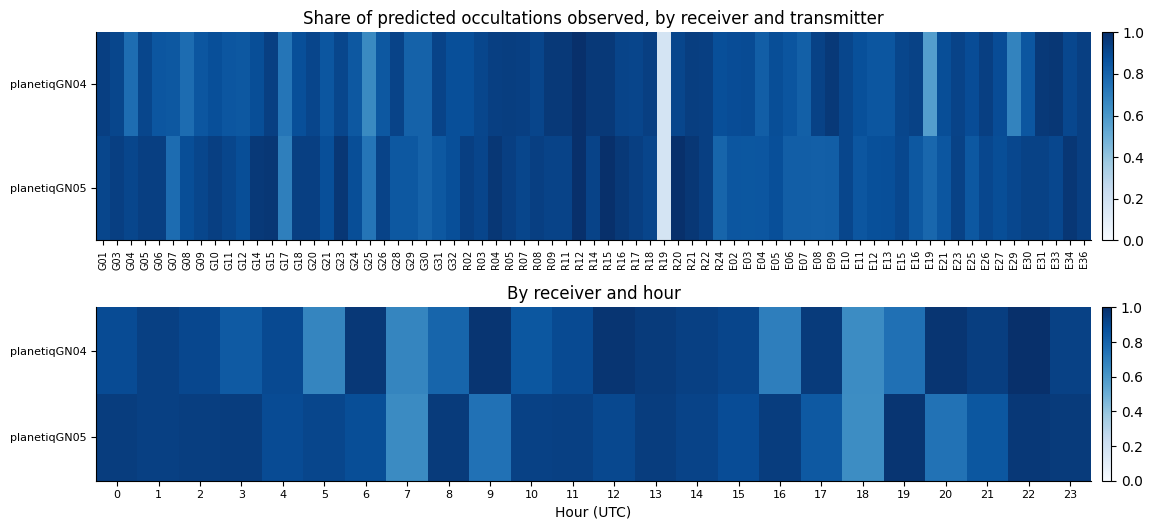

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update(
    {"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6}
)

pred = predicted.copy()
pred["seen"] = False
pred.loc[pairs.pred, "seen"] = True
pred["yaw"] = folded(pred.rx_tx_yaw)
pred["hour"] = pred.time.dt.hour
pred["concurrent"] = [  # other predicted occultations of the same receiver and direction overlapping in time
    int(
        (
            (pred.receiver == r.receiver)
            & (pred.is_rising == r.is_rising)
            & (pred.start < r.end)
            & (pred.end > r.start)
            & (pred.index != r.Index)
        ).sum()
    )
    for r in pred.itertuples()
]
order = sorted(pred.transmitter.unique(), key=lambda tx: ("GRE".index(tx[0]), tx))
by_pair = pred.pivot_table(index="receiver", columns="transmitter", values="seen", aggfunc="mean")[order]
hourly = pred.groupby(["hour", "receiver"])["seen"].mean().unstack()  # hours x receivers

fig, axes = plt.subplots(2, 1, figsize=(13, 5.4), gridspec_kw={"height_ratios": [1.2, 1]})
im = axes[0].imshow(by_pair.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(by_pair.shape[1]), by_pair.columns, rotation=90, fontsize=7)
axes[0].set_yticks(range(by_pair.shape[0]), by_pair.index, fontsize=8)
axes[0].grid(False)
axes[0].set_title("Share of predicted occultations observed, by receiver and transmitter")
fig.colorbar(im, ax=axes[0], pad=0.01)
im = axes[1].imshow(hourly.T.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(hourly.shape[0]), hourly.index, fontsize=8)
axes[1].set_yticks(range(hourly.shape[1]), hourly.columns, fontsize=8)
axes[1].grid(False)
axes[1].set(xlabel="Hour (UTC)", title="By receiver and hour")
fig.colorbar(im, ax=axes[1], pad=0.01)
fig.tight_layout()
plt.show()

Every receiver-transmitter combination was recorded regularly (none below the 10% threshold used to exclude untracked combinations for COSMIC-2), so all predictions enter the breakdown by constellation, geometry, and tracking load:

In [6]:
seen_rate = pred.groupby(["receiver", "transmitter"])["seen"].transform("mean")
tracked = pred[seen_rate > 0.1]
groups = {
    "constellation": pd.Categorical(tracked.constellation, categories=list(CONSTELLATIONS.values())),
    # arcs cut off by the yaw limit report a yaw of exactly max_yaw (up to round-off)
    "yaw from fore/aft (deg)": pd.cut(
        tracked.yaw.clip(upper=MAX_YAW), [b for b in [0, 15, 30, 45, 55, 60, 65, 70, 75, 80] if b < MAX_YAW] + [MAX_YAW]
    ),
    "direction": tracked.is_rising.map({True: "rising", False: "setting"}),
    "other same-direction occultations at the same time": pd.Categorical(
        tracked.concurrent.clip(upper=3).astype(str).replace("3", "3 or more"), categories=["0", "1", "2", "3 or more"]
    ),
}
print(f"{len(tracked)} of {len(pred)} predicted occultations in receiver-transmitter combinations observed at least 10% of the time")
pd.concat(
    {name: tracked.groupby(key, observed=True)["seen"].agg(["mean", "size"]) for name, key in groups.items()}
).rename(columns={"mean": "share observed", "size": "predicted"}).round(2)

4357 of 4357 predicted occultations in receiver-transmitter combinations observed at least 10% of the time


share observed  \
constellation                                      GPS                  0.88   
                                                   GLONASS              0.89   
                                                   Galileo              0.88   
yaw from fore/aft (deg)                            (0, 15]              0.90   
                                                   (15, 30]             0.92   
                                                   (30, 45]             0.90   
                                                   (45, 55]             0.87   
                                                   (55, 60]             0.85   
                                                   (60, 65]             0.86   
                                                   (65, 70]             0.82   
                                                   (70, 75]             0.74   
                                                   (75, 80]             0.67   
                                                   (80, 84]             0.40   
direction                                          rising               0.85   
                                                   setting              0.91   
other same-direction occultations at the same time 0                    0.92   
                                                   1                    0.90   
                                                   2                    0.90   
                                                   3 or more            0.86   

                                                              predicted  
constellation                                      GPS             1577  
                                                   GLONASS         1201  
                                                   Galileo         1579  
yaw from fore/aft (deg)                            (0, 15]          945  
                                                   (15, 30]        1087  
                                                   (30, 45]        1148  
                                                   (45, 55]         506  
                                                   (55, 60]         202  
                                                   (60, 65]         160  
                                                   (65, 70]          92  
                                                   (70, 75]         105  
                                                   (75, 80]          64  
                                                   (80, 84]          48  
direction                                          rising          2182  
                                                   setting         2175  
other same-direction occultations at the same time 0                197  
                                                   1                700  
                                                   2               1148  
                                                   3 or more       2312

Unlike COSMIC-2, PlanetiQ tracks the three constellations alike (86 to 90% of predicted occultations recorded for every receiver and constellation) and shows no extended data gaps: both receivers recorded at least 64% of the predicted occultations in every hour. The one exception is GLONASS R19, which both receivers recorded for only 18% of its predicted occultations, although COSMIC-2 recorded most of them; every other transmitter was recorded at least 68% of the time (lowest for Galileo E19 and GPS G25). The recorded share is nearly independent of yaw angle up to 65 deg (81 to 93% for each constellation) and falls beyond it as PlanetiQ's antenna coverage tapers off: to 71 to 89% between 65 and 75 deg, 59 to 76% between 75 and 80 deg, and 40% between 80 and 84 deg, where GLONASS (71%) fares much better than GPS (33%) and Galileo (12%). Setting occultations were recorded more often than rising ones for GPS and Galileo (91 to 92% vs 83 to 84%) but hardly for GLONASS (90% vs 88%), and the share decreases only slightly when several occultations compete for the same receiver. Since TAT-C predicts all of PlanetiQ's recorded occultations, PlanetiQ recorded 88% (GPS and Galileo) to 89% (GLONASS) as many occultations as TAT-C predicts with an 84 deg `max_yaw`.

## Test 4: Timing and Location of Matched Occultations

For each matched occultation in the samples, TAT-C's `time` and `position` (at -80 km) are compared with the true straight-line tangent point, computed with the same tangent point routine from the recorded receiver and transmitter positions.

In [7]:
from pyproj import Geod, Transformer

from tatc.analysis.tangent_point import _ellipsoidal_tangent_point, _itrs_rotation

GEOD = Geod(ellps="WGS84")
TO_LLA = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)


def to_lla(p):
    """Geodetic longitude (deg), latitude (deg), and altitude (m) of Earth-fixed positions (3, N)."""
    return tuple(np.asarray(x) for x in TO_LLA.transform(p[0], p[1], p[2]))


def tangent_points(rx, tx, t):
    """TAT-C's straight-line tangent points (Earth-fixed, m) for Earth-fixed receiver and
    transmitter positions (3, N) at Skyfield times t (the routine works in the inertial frame)."""
    rotation = _itrs_rotation(t)
    to_gcrs = lambda p: np.einsum("jin,jn->in", rotation, p)  # noqa: E731
    tp = _ellipsoidal_tangent_point(to_gcrs(rx), to_gcrs(tx - rx), t)
    return np.einsum("ijn,jn->in", rotation, tp)


def crossing(t, h, value):
    """Time at which h(t) first crosses value (linear interpolation), or NaN."""
    c = np.nonzero(np.diff(np.sign(h - value)))[0]
    if len(c) == 0:
        return np.nan
    j = c[0]
    return t[j] + (value - h[j]) / (h[j + 1] - h[j]) * (t[j + 1] - t[j])


def interpolate(t, p, times):
    return np.array([np.interp(times, t, p[i]) for i in range(3)])


# true time and location at which each sampled occultation's straight line reaches -80 km,
# from the recorded receiver and transmitter positions (subsampled to 10 Hz)
truth = {}
for record in sample._data:
    l1 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_calibratedPhase"])))
    l1.set_auto_mask(False)
    t, rx, tx = l1["time"][:], l1["positionLEO"][:].T, l1["positionGNSS"][:].T
    ok = (np.abs(t) < 1e10) & np.all(np.abs(rx) < 1e10, axis=0) & np.all(np.abs(tx) < 1e10, axis=0)
    i = np.nonzero(ok)[0][::10]
    start = float(l1["startTime"][...])
    # GPS seconds since 1980-01-06 are TAI - 19 s
    points = tangent_points(rx[:, i], tx[:, i], timescale.tai_jd(2444244.5 + (start + t[i] + 19) / 86400))
    t_80 = crossing(t[i], to_lla(points)[2], -80e3)
    if np.isfinite(t_80):
        lon, lat, _ = to_lla(interpolate(t[i], points, [t_80]))
        truth[record["occid"]] = (GPS_EPOCH + timedelta(seconds=start - GPS_UTC_OFFSET + t_80), lon[0], lat[0])

rows = []
for i, j in zip(pairs.pred, pairs.obs):
    p, o = pred.loc[i], observed.loc[j]
    if o.occid in truth:
        true_time, lon, lat = truth[o.occid]
        rows.append(
            {
                "constellation": o.constellation,
                "TAT-C time minus true time at -80 km (s)": (p.time.to_pydatetime() - true_time).total_seconds(),
                "TAT-C position: -80 km point to truth (km)": GEOD.inv(p.position.x, p.position.y, lon, lat)[2] / 1e3,
            }
        )
accuracy = pd.DataFrame(rows)
pd.concat(
    {
        c: accuracy[accuracy.constellation == c].drop(columns="constellation").describe(percentiles=[0.5, 0.95]).T
        for c in CONSTELLATIONS.values()
    }
).round(3)

count   mean    std  \
GPS     TAT-C time minus true time at -80 km (s)    200.0  0.013  0.129   
        TAT-C position: -80 km point to truth (km)  200.0  0.455  0.365   
GLONASS TAT-C time minus true time at -80 km (s)    200.0  0.018  0.129   
        TAT-C position: -80 km point to truth (km)  200.0  0.499  0.438   
Galileo TAT-C time minus true time at -80 km (s)    200.0 -0.003  0.140   
        TAT-C position: -80 km point to truth (km)  200.0  0.468  0.554   

                                                      min    50%    95%    max  
GPS     TAT-C time minus true time at -80 km (s)   -0.371  0.004  0.212  0.366  
        TAT-C position: -80 km point to truth (km)  0.012  0.332  1.165  1.853  
GLONASS TAT-C time minus true time at -80 km (s)   -0.229  0.007  0.245  0.508  
        TAT-C position: -80 km point to truth (km)  0.003  0.368  1.225  3.071  
Galileo TAT-C time minus true time at -80 km (s)   -0.692  0.004  0.184  0.578  
        TAT-C position: -80 km point to truth (km)  0.017  0.333  1.180  4.108

For all three constellations, TAT-C's `time` agrees with the true time at which the straight line reaches -80 km to within 0.18 to 0.25 s (95th percentile), and its `position` with the true straight-line tangent point to 0.33 to 0.37 km (median) and 1.2 km (95th percentile), for all 200 sampled occultations of each constellation, limited by orbit accuracy.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbits (TLEs vs. recorded positions) | All 71 transmitters (26 GPS, 19 GLONASS, 26 Galileo) and both receivers identified; within about 5 km (GPS), 7 km (GLONASS), and 16 km (Galileo), with no element sets excluded |
| 2. Predicted vs. observed (`max_yaw` = 84 deg) | All 3,838 observed occultations predicted, with correct rising/setting; 88% of the 4,357 predicted occultations recorded (88 to 89% per constellation) |
| 3. Detection | Constellations tracked alike, with no untracked combinations or data gaps (except GLONASS R19, 18% recorded); recorded share nearly independent of yaw angle up to 65 deg, falling to 40% at 80-84 deg |
| 4. Timing and location | `time` within 0.18 to 0.25 s (95th percentile); `position` 0.33 to 0.37 km (median) and 1.2 km (95th percentile) from the true tangent point |

**TAT-C's RO geometry is validated for a polar orbit and three constellations.** With published orbits and a `max_yaw` of 84 deg, `collect_ro_observations` predicts every GPS, GLONASS, and Galileo occultation PlanetiQ recorded on this day, labels each correctly as rising or setting, and reports its time to a fraction of a second and its position to a third of a kilometer (median), limited by orbit accuracy. PlanetiQ recorded 88% of TAT-C's predictions, with no untracked transmitters or data gaps apart from GLONASS R19, so predicted counts are close to recorded counts for every constellation.

**PlanetiQ's coverage extends beyond the default `max_yaw`.** The 65 deg default matches COSMIC-2's coverage, but PlanetiQ observes occultations up to 84 deg from its forward or rearward direction for all three constellations, and a `max_yaw` of 84 deg predicts all of them. Predictions beyond 65 deg are recorded progressively less often as the antenna coverage tapers off (59 to 76% between 75 and 80 deg and 40% between 80 and 84 deg), so they add more predicted than recorded occultations; a smaller `max_yaw` trades a few missed occultations for a closer match between predicted and recorded counts.

**Next steps:**

1. *BeiDou.* PlanetiQ also tracks BeiDou (1,473 occultations with a retrieval on this day); adding BeiDou orbits would extend the comparison to a fourth constellation.
2. *More receivers.* Repeat for Spire's receivers, which fly in polar orbits at altitudes from about 410 to 575 km.
3. *More days.* Repeat on additional days to confirm that the detection shares and the observed yaw coverage are stable.

**Limitations.** This study covers one day and UCAR processing only; the orbit and timing checks (Tests 1 and 4) use random samples of 200 occultations per constellation.